In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time

In [2]:
bike_data = []
brands = ["bajaj", "royalenfield", "tvs", "honda", "jawa", "triumph", "ktm"]
for i in brands:
    # Temporary lists for each brand
    bike_name = []
    bike_cc = []
    bike_kmpl = []
    bike_bhp = []
    bike_kg = []
    bike_price = []
    bike_rating = []
    url = f"https://www.bikewale.com/{i}-bikes/"
    time.sleep(2)
    page = requests.get(url)
    soup = BeautifulSoup(page.text)
    # extract links 
    bike_names = soup.find_all('h3',class_="o-j4 o-jq o-hM o-c4 o-jK")
    bike_details = soup.find_all('div',class_="o-o FTJfQA o-iT o-ei")
    bike_prices = soup.find_all('span',class_="o-jJ o-jr o-j3 o-kJ")
    bike_ratings = soup.find_all('p',class_="o-iY o-cx o-jq o-d o-j o-jJ")
    # Bike Names
    for item in bike_names:
        bike_name.append(item.text.strip() if item.text else np.nan)
    # CC
    for item in bike_details:
        text = item.text
        regex = re.findall(r'\d+(?:\.\d+)?\s*cc',text,re.IGNORECASE)
        if regex:
            bike_cc.append(regex[0])
        else:
            bike_cc.append(np.nan)
    # Mileage
    for item in bike_details:
        text = item.text
        regex = re.findall(r'\d+(?:\.\d+)?\s*kmpl',text,re.IGNORECASE)
        if not regex:
            regex = re.findall(r'\d+(?:\.\d+)?\s*kmph',text,re.IGNORECASE)
        if regex:
            bike_kmpl.append(regex[0])
        else:
            bike_kmpl.append(np.nan)
    # Power
    for item in bike_details:
        text = item.text
        regex = re.findall(r'\d+(?:\.\d+)?\s*bhp',text,re.IGNORECASE)
        if not regex:
            regex = re.findall(r'\d+(?:\.\d+)?\s*kW',text,re.IGNORECASE)
        if regex:
            bike_bhp.append(regex[0])
        else:
            bike_bhp.append(np.nan)
    # Weight
    for item in bike_details:
        text = item.text
        regex = re.findall(r'\d+(?:\.\d+)?\s*kg',text,re.IGNORECASE)
        if regex:
            bike_kg.append(regex[0])
        else:
            bike_kg.append(np.nan)
    # Price
    for item in bike_prices:
        bike_price.append(item.text.strip() if item.text else np.nan)
    # Rating
    for item in bike_ratings:
        text = item.text.strip()
        if text:
            bike_rating.append(text.split('/')[0])
        else:
            bike_rating.append(np.nan)
    # CHECK LENGTHS
    print("Names   :", len(bike_name))
    print("CC      :", len(bike_cc))
    print("Mileage :", len(bike_kmpl))
    print("Power   :", len(bike_bhp))
    print("Weight  :", len(bike_kg))
    print("Price   :", len(bike_price))
    print("Rating  :", len(bike_rating))
    # CREATE DATAFRAME FOR
    # CURRENT BRAND
    brand_dict = {
        "Brand": pd.Series([i] * len(bike_name)),
        "Bike_Name": pd.Series(bike_name),
        "CC": pd.Series(bike_cc),
        "Mileage": pd.Series(bike_kmpl),
        "Power": pd.Series(bike_bhp),
        "Weight": pd.Series(bike_kg),
        "Price": pd.Series(bike_price),
        "Rating": pd.Series(bike_rating)
    }
    brand_df = pd.DataFrame(brand_dict)
    # Add current brand data to final data
    bike_data.append(brand_df)
# COMBINE ALL BRANDS
df = pd.concat(bike_data,ignore_index=True)
# DISPLAY RESULT
print("\nFinal DataFrame:")
print(df)
print("\nFinal Shape:")
print(df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nNumber of bikes by brand:")
print(df["Brand"].value_counts())

Names   : 27
CC      : 23
Mileage : 23
Power   : 23
Weight  : 23
Price   : 23
Rating  : 23
Names   : 24
CC      : 17
Mileage : 17
Power   : 17
Weight  : 17
Price   : 17
Rating  : 17
Names   : 28
CC      : 22
Mileage : 22
Power   : 22
Weight  : 22
Price   : 22
Rating  : 22
Names   : 36
CC      : 27
Mileage : 27
Power   : 27
Weight  : 27
Price   : 27
Rating  : 26
Names   : 5
CC      : 5
Mileage : 5
Power   : 5
Weight  : 5
Price   : 5
Rating  : 5
Names   : 31
CC      : 29
Mileage : 29
Power   : 29
Weight  : 29
Price   : 29
Rating  : 25
Names   : 31
CC      : 24
Mileage : 24
Power   : 24
Weight  : 24
Price   : 24
Rating  : 21

Final DataFrame:
     Brand             Bike_Name         CC  Mileage      Power  Weight  \
0    bajaj  Bajaj Pulsar N160 2V  164.82 cc  47 kmpl  15.68 bhp  148 kg   
1    bajaj   Bajaj Pulsar NS400Z  349.13 cc  32 kmpl  40.04 bhp  176 kg   
2    bajaj    Bajaj Pulsar NS200   199.5 cc  36 kmpl  24.13 bhp  158 kg   
3    bajaj      Bajaj Pulsar 125   124.4 cc  50 kmpl

In [3]:
df

,Brand,Bike_Name,CC,Mileage,Power,Weight,Price,Rating
0,bajaj,Bajaj Pulsar N160 2V,164.82 cc,47 kmpl,15.68 bhp,148 kg,"₹ 1,22,990",4.6
1,bajaj,Bajaj Pulsar NS400Z,349.13 cc,32 kmpl,40.04 bhp,176 kg,"₹ 1,86,150",4.5
2,bajaj,Bajaj Pulsar NS200,199.5 cc,36 kmpl,24.13 bhp,158 kg,"₹ 1,39,279",4.7
3,bajaj,Bajaj Pulsar 125,124.4 cc,50 kmpl,11.8 bhp,NaN,"₹ 93,507",3.6
4,bajaj,Bajaj Pulsar N160 4V,164.5 cc,46 kmpl,18.24 bhp,151 kg,"₹ 1,34,479",4.5
...,...,...,...,...,...,...,...,...
177,ktm,KTM 890 Duke,NaN,NaN,NaN,NaN,NaN,NaN
178,ktm,KTM RC 350,NaN,NaN,NaN,NaN,NaN,NaN
179,ktm,KTM 650 Duke,NaN,NaN,NaN,NaN,NaN,NaN
180,ktm,KTM 490 Duke,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.to_csv("bikewale_bikes.csv",index=False)
print("\nCSV saved successfully!")


CSV saved successfully!


#  Data cleaning 

In [5]:
df["CC"] = df["CC"].str.replace("cc", "").str.strip()
#df["Mileage"] = df["Mileage"].str.replace(["kmpl","kmph"], "").str.strip()
#df["Power"] = df["Power"].str.replace("bhp", "").str.strip()
df["Weight"] = df["Weight"].str.replace("kg", "").str.strip()
df["Price"] = (df["Price"].str.replace("₹", "").str.replace(",", "").str.strip())

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Brand      182 non-null    object
 1   Bike_Name  182 non-null    object
 2   CC         139 non-null    object
 3   Mileage    109 non-null    object
 4   Power      145 non-null    object
 5   Weight     142 non-null    object
 6   Price      147 non-null    object
 7   Rating     139 non-null    object
dtypes: object(8)
memory usage: 11.5+ KB


In [7]:
df['CC']=df["CC"].astype(float)

df['Weight']=df["Weight"].astype(float)
df['Price']=df["Price"].astype(float)
df['Rating']=df["Rating"].astype(float)

In [8]:
df["Mileage"] = df["Mileage"].str.replace("kmpl", "").str.strip()

In [9]:
df["Mileage"] = df["Mileage"].str.replace("kmph", "").str.strip()

In [10]:
df['Mileage']=df["Mileage"].astype(float)

In [11]:
df["Power"] = df["Power"].str.replace("kW", "").str.strip()

In [12]:
df["Power"] = df["Power"].str.replace("bhp", "").str.strip()

In [13]:
df['Power']=df["Power"].astype(float)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Brand      182 non-null    object 
 1   Bike_Name  182 non-null    object 
 2   CC         139 non-null    float64
 3   Mileage    109 non-null    float64
 4   Power      145 non-null    float64
 5   Weight     142 non-null    float64
 6   Price      147 non-null    float64
 7   Rating     139 non-null    float64
dtypes: float64(6), object(2)
memory usage: 11.5+ KB


In [15]:
df=df.drop(df[df['CC'].isnull() & df['Mileage'].isnull() & df['Power'].isnull() & df['Weight'].isnull() & df['Price'].isnull() & df['Rating'].isnull()].index)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 174
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Brand      147 non-null    object 
 1   Bike_Name  147 non-null    object 
 2   CC         139 non-null    float64
 3   Mileage    109 non-null    float64
 4   Power      145 non-null    float64
 5   Weight     142 non-null    float64
 6   Price      147 non-null    float64
 7   Rating     139 non-null    float64
dtypes: float64(6), object(2)
memory usage: 10.3+ KB


In [17]:
df = df.reset_index(drop=True)

In [18]:
df["Rating"] = df['Rating'].fillna(df['Rating'].mean())

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Brand      147 non-null    object 
 1   Bike_Name  147 non-null    object 
 2   CC         139 non-null    float64
 3   Mileage    109 non-null    float64
 4   Power      145 non-null    float64
 5   Weight     142 non-null    float64
 6   Price      147 non-null    float64
 7   Rating     147 non-null    float64
dtypes: float64(6), object(2)
memory usage: 9.3+ KB


In [20]:
df["Weight"] = df['Weight'].fillna(df['Weight'].mean())

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Brand      147 non-null    object 
 1   Bike_Name  147 non-null    object 
 2   CC         139 non-null    float64
 3   Mileage    109 non-null    float64
 4   Power      145 non-null    float64
 5   Weight     147 non-null    float64
 6   Price      147 non-null    float64
 7   Rating     147 non-null    float64
dtypes: float64(6), object(2)
memory usage: 9.3+ KB


In [22]:
df['CC'].unique()

array([ 164.82,  349.13,  199.5 ,  124.4 ,  164.5 ,     nan,  124.45,
        249.  ,  149.5 ,  160.3 ,  220.  ,  248.8 ,  124.58,  125.  ,
         99.59,  115.45,  178.61,  349.34,  349.  ,  443.  ,  648.  ,
        452.  ,  451.65,  647.95,  124.8 ,  159.7 ,  225.9 ,  113.3 ,
        312.2 ,  299.  ,  312.12,   99.7 ,  197.75,  149.7 ,  109.7 ,
        177.4 ,  123.94,  109.51,  348.36,  162.71,  286.  ,  123.92,
        184.4 ,  156.9 ,   98.98, 1000.  ,  471.  , 1833.  ,  755.  ,
        999.  ,  334.  ,  294.72,  765.  , 2458.  ,  660.  , 1200.  ,
        888.  ,  900.  , 1160.  ,  249.07,  349.32,  164.2 ,  248.76,
        398.63,  398.7 , 1350.  ,  373.27,  889.  , 1301.  ,   84.9 ,
        449.9 ,   49.9 ,  249.9 ,  349.7 ,   64.9 ])

In [23]:
less_than_125 = df.loc[df['CC'] <= 125]
less_than_125_avg  = less_than_125['Mileage'].mean()
less_than_125_avg

np.float64(56.56)

In [24]:
less_than_126_300 = df.loc[df['CC'].between(126, 300)]
less_than_126_300
less_than_126_300_avg = less_than_126_300['Mileage'].mean()
less_than_126_300_avg

np.float64(39.706896551724135)

In [25]:
less_than_300_600 = df.loc[df['CC'].between(300,600)]
less_than_300_600
less_than_300_600_avg= less_than_300_600['Mileage'].mean()
less_than_300_600_avg

np.float64(30.742424242424242)

In [26]:
less_than_600_1200 = df.loc[df['CC'].between(600,1200)]
less_than_600_1200
less_than_600_1200_avg=less_than_600_1200['Mileage'].mean()
less_than_600_1200_avg

np.float64(21.954545454545453)

In [27]:
less_than_1200_2458 = df.loc[df['CC'].between(1200,2458)]
less_than_1200_2458
less_than_1200_2458_avg=less_than_1200_2458['Mileage'].mean()
less_than_1200_2458_avg

np.float64(19.5)

In [28]:
mask = (df['CC'] <= 125)
df.loc[mask, 'Mileage'] = df.loc[mask, 'Mileage'].fillna(less_than_125_avg)

In [29]:
mask = (df['CC'].between(126,300))
df.loc[mask, 'Mileage'] = df.loc[mask, 'Mileage'].fillna(less_than_126_300_avg)
mask

0       True
1      False
2       True
3      False
4       True
       ...  
142    False
143    False
144     True
145    False
146    False
Name: CC, Length: 147, dtype: bool

In [30]:
mask = (df['CC'].between(300,600))
df.loc[mask, 'Mileage'] = df.loc[mask, 'Mileage'].fillna(less_than_300_600_avg)


In [31]:
mask = (df['CC'].between(600,1200))
df.loc[mask, 'Mileage'] = df.loc[mask, 'Mileage'].fillna(less_than_600_1200_avg)

In [32]:
mask = (df['CC'].between(1200,2458))
df.loc[mask, 'Mileage'] = df.loc[mask, 'Mileage'].fillna(less_than_1200_2458_avg)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Brand      147 non-null    object 
 1   Bike_Name  147 non-null    object 
 2   CC         139 non-null    float64
 3   Mileage    147 non-null    float64
 4   Power      145 non-null    float64
 5   Weight     147 non-null    float64
 6   Price      147 non-null    float64
 7   Rating     147 non-null    float64
dtypes: float64(6), object(2)
memory usage: 9.3+ KB


In [34]:
bajaj_cc_mean = df.loc[(df['Brand'] == 'bajaj') & (df['Mileage'].between(55, 70))]
bajaj_cc_mean_avg = bajaj_cc_mean['CC'].median()

In [35]:
df.loc[df['Brand'] == 'bajaj', 'CC'] = (df.loc[df['Brand'] == 'bajaj', 'CC'].fillna(bajaj_cc_mean_avg))

In [36]:
tvs_cc_mean = df.loc[(df['Brand'] == 'tvs') & (df['Mileage'].between(50,150))]
tvs_cc_mean_avg = tvs_cc_mean['CC'].median()
tvs_cc_mean_avg
df.loc[df['Brand'] == 'tsv','CC'] = (df.loc[df['Brand'] == 'tvs', 'CC'].fillna(tvs_cc_mean_avg))

In [37]:
honda_cc_mean = df.loc[(df['Brand'] == 'honda') & (df['Mileage'].between(0,100))]
honda_cc_mean_avg = honda_cc_mean['CC'].median()
honda_cc_mean_avg
df.loc[df['Brand'] == 'honda','CC'] = (df.loc[df['Brand'] == 'honda', 'CC'].fillna(honda_cc_mean_avg))

In [38]:
df

,Brand,Bike_Name,CC,Mileage,Power,Weight,Price,Rating
0,bajaj,Bajaj Pulsar N160 2V,164.82,47.000000,15.68,148.000000,122990.0,4.600000
1,bajaj,Bajaj Pulsar NS400Z,349.13,32.000000,40.04,176.000000,186150.0,4.500000
2,bajaj,Bajaj Pulsar NS200,199.50,36.000000,24.13,158.000000,139279.0,4.700000
3,bajaj,Bajaj Pulsar 125,124.40,50.000000,11.80,169.120423,93507.0,3.600000
4,bajaj,Bajaj Pulsar N160 4V,164.50,46.000000,18.24,151.000000,134479.0,4.500000
...,...,...,...,...,...,...,...,...
142,ktm,KTM 450 SX-F,449.90,30.742424,62.10,107.000000,1025100.0,3.700000
143,ktm,KTM 50 SX,49.90,56.560000,5.30,45.000000,475000.0,4.500000
144,ktm,KTM 250 SX-F,249.90,39.706897,46.10,104.000000,958000.0,4.360432
145,ktm,KTM 350 EXC-F,349.70,30.742424,44.30,103.200000,1295800.0,4.360432


In [39]:
df = df.dropna(subset=['CC'])

In [40]:
df['Power'] = df['Power'].fillna(df['Power'].mean())

C:\Users\Kiran\AppData\Local\Temp\ipykernel_23128\215560432.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Power'] = df['Power'].fillna(df['Power'].mean())


df.info()

In [64]:
df.to_csv("cleaned_data.csv",index=False)

Index(['Brand', 'Bike_Name', 'CC', 'Mileage', 'Power', 'Weight', 'Price',
       'Rating'],
      dtype='object')

# Data Analysis

# Univariate Analysis Questions
##### What is the distribution of motorcycle engine capacity (CC) in the dataset?
##### How are motorcycle prices distributed across all listed bikes?
##### What is the distribution of customer ratings for motorcycles?
##### Which motorcycle brand has the highest number of models listed?
##### What is the distribution of motorcycle mileage (kmpl)?

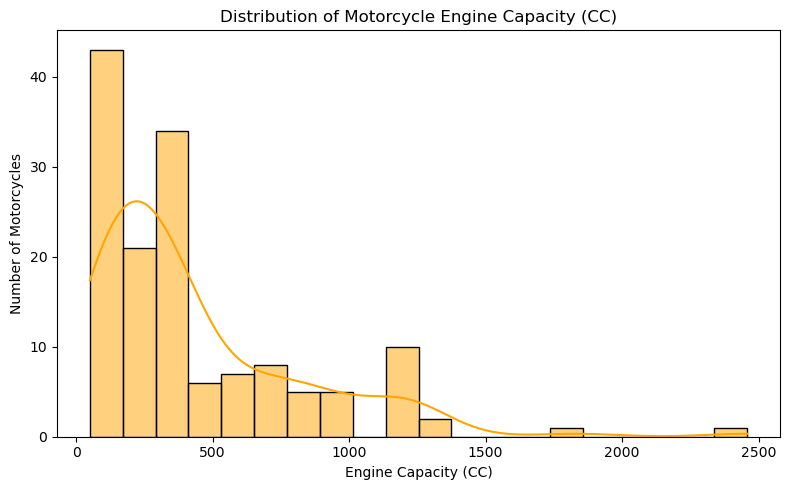

In [80]:
# What is the distribution of motorcycle engine capacity (CC) in the dataset?
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='CC', kde=True, color='orange', bins=20)
plt.title("Distribution of Motorcycle Engine Capacity (CC)")
plt.xlabel('Engine Capacity (CC)')
plt.ylabel('Number of Motorcycles')
plt.tight_layout()
plt.show()

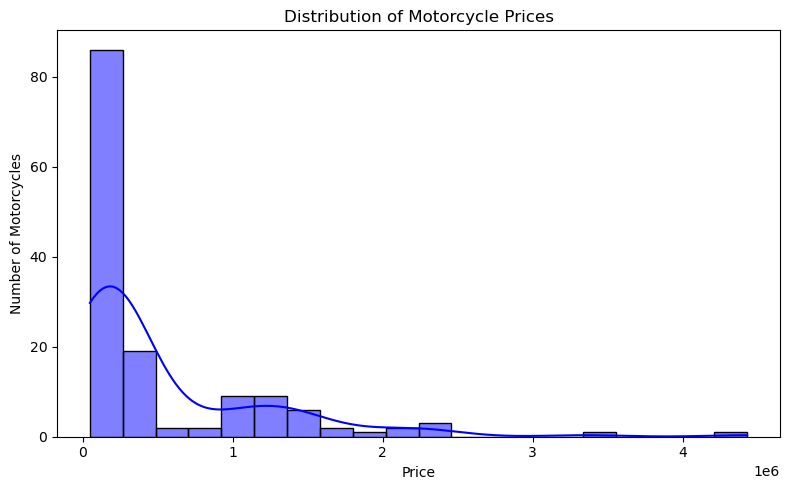

In [83]:
#How are motorcycle prices distributed across all listed bikes?
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Price', kde=True, color='blue', bins=20)
plt.title("Distribution of Motorcycle Prices")
plt.xlabel('Price')
plt.ylabel('Number of Motorcycles')
plt.tight_layout()
plt.show()

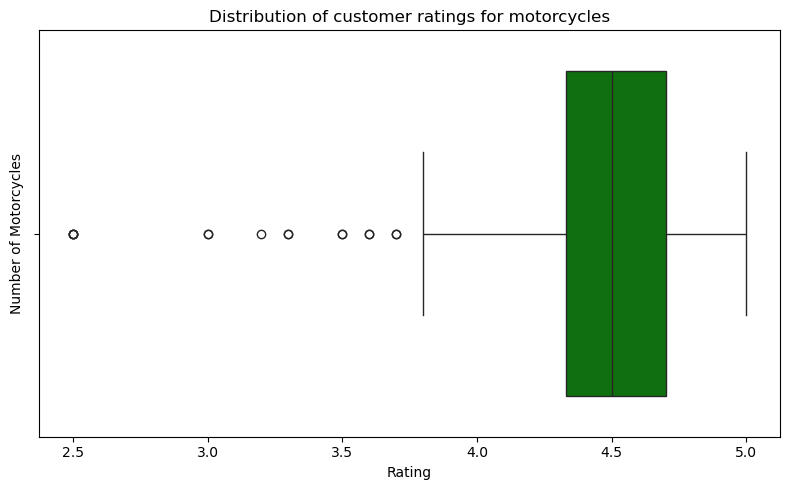

In [92]:
#What is the distribution of customer ratings for motorcycles?
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Rating', color='green')
plt.title("Distribution of customer ratings for motorcycles")
plt.xlabel('Rating')
plt.ylabel('Number of Motorcycles')
plt.tight_layout()
plt.show()

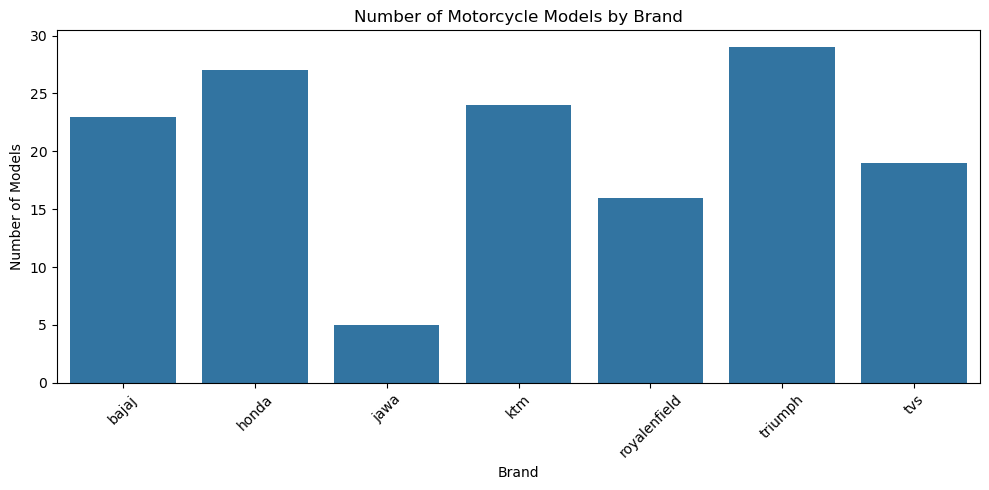

In [99]:
#Which motorcycle brand has the highest number of models listed?
number_of_models = df.groupby('Brand')['Bike_Name'].count()
plt.figure(figsize=(10,5))
sns.barplot(x=number_of_models.index,y=number_of_models.values)
plt.title("Number of Motorcycle Models by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

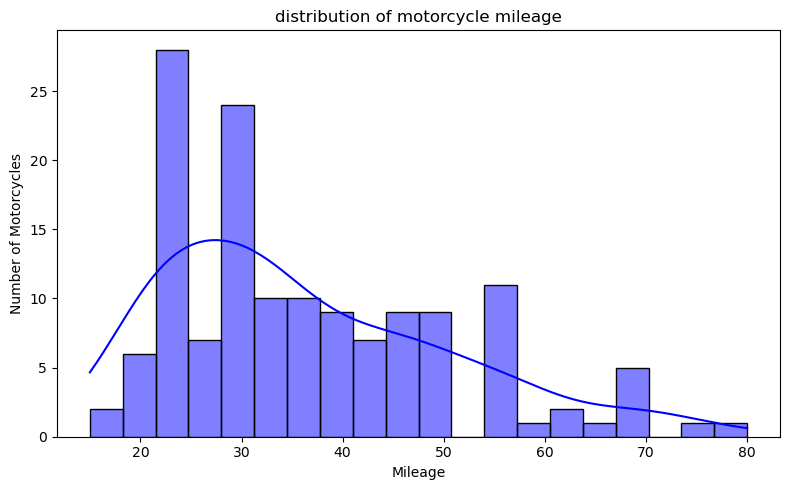

In [101]:
#What is the distribution of motorcycle mileage (kmpl)?
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Mileage', kde=True, color='blue', bins=20)
plt.title("distribution of motorcycle mileage")
plt.xlabel('Mileage')
plt.ylabel('Number of Motorcycles')
plt.tight_layout()
plt.show()

### Bivariate Analysis Questions 
##### Is there a relationship between engine capacity (CC) and motorcycle price?
##### Does higher engine power lead to higher motorcycle prices?
##### What is the relationship between motorcycle weight and price?
##### Are higher-rated motorcycles generally more expensive?
##### Does engine capacity (CC) have a positive relationship with power output?

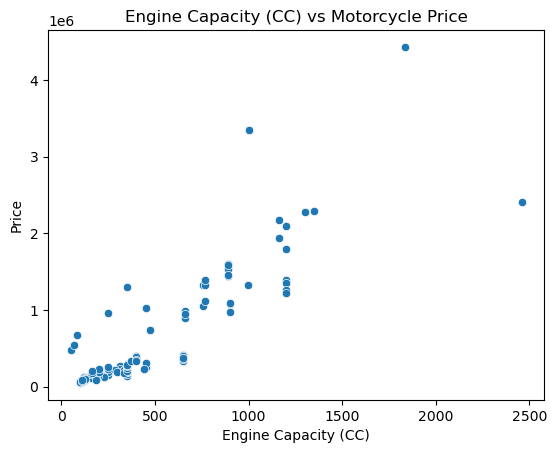

In [103]:
# Is there a relationship between engine capacity (CC) and motorcycle price?
sns.scatterplot(data=df, x='CC', y='Price')
plt.title('Engine Capacity (CC) vs Motorcycle Price')
plt.xlabel('Engine Capacity (CC)')
plt.ylabel('Price')
plt.show()

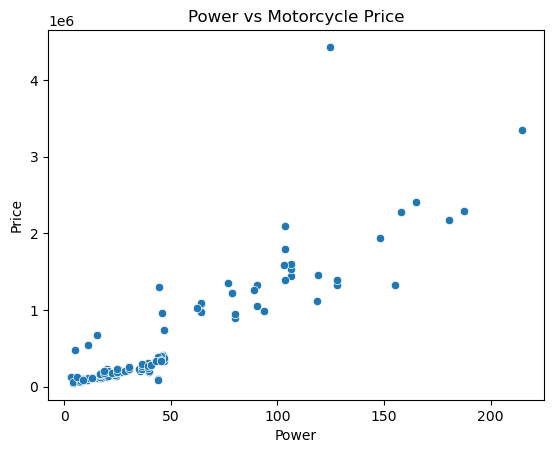

In [105]:
# Does higher engine power lead to higher motorcycle prices?
sns.scatterplot(data=df, x='Power', y='Price')
plt.title('Power vs Motorcycle Price')
plt.xlabel('Power')
plt.ylabel('Price')
plt.show()

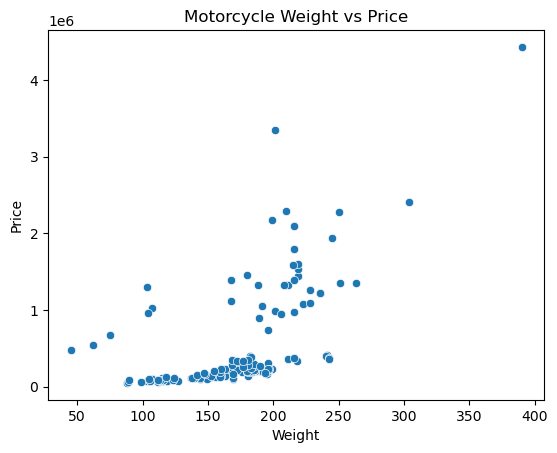

In [112]:
# What is the relationship between motorcycle weight and price?
sns.scatterplot(data=df, x='Weight', y='Price')
plt.title('Motorcycle Weight vs Price')
plt.xlabel('Weight')
plt.ylabel('Price')
plt.show()

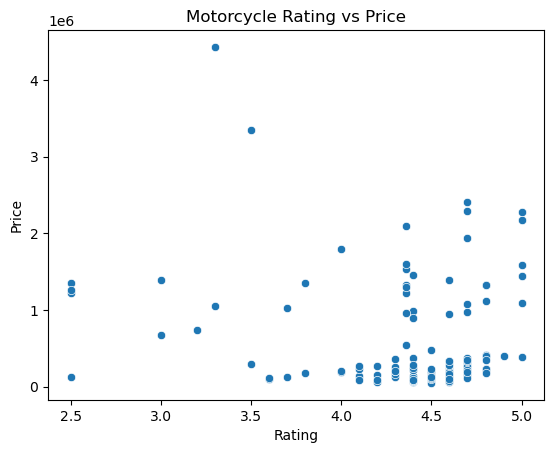

In [111]:
# Are higher-rated motorcycles generally more expensive?
sns.scatterplot(data=df, x='Rating', y='Price')
plt.title('Motorcycle Rating vs Price')
plt.xlabel('Rating')
plt.ylabel('Price')
plt.show()

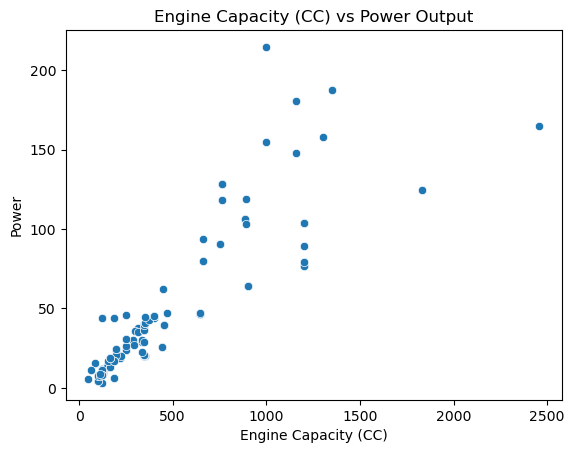

In [110]:
# Does engine capacity (CC) have a positive relationship with power output?
sns.scatterplot(data=df, x='CC', y='Power')
plt.title('Engine Capacity (CC) vs Power Output')
plt.xlabel('Engine Capacity (CC)')
plt.ylabel('Power')
plt.show()

# Multivariate Analysis
##### How do CC, Power, and Weight together influence motorcycle price?
##### Which motorcycles offer the best combination of low price, high rating, and good mileage?
##### How do Brand, Price, and Rating interact across different motorcycle manufacturers?

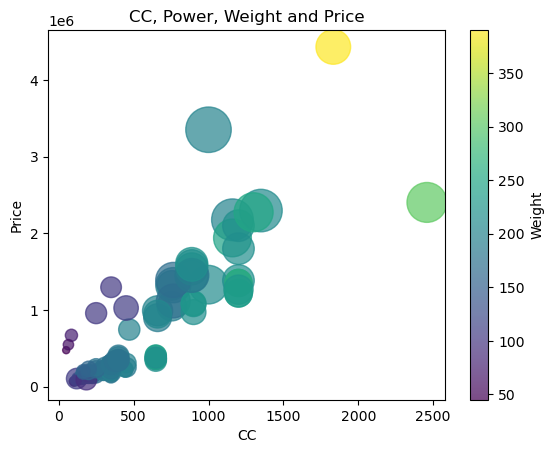

In [144]:
# How do CC, Power, and Weight together influence motorcycle price?
plt.scatter(df['CC'],df['Price'],s=df['Power'] * 5,c=df['Weight'],alpha=0.7)
plt.colorbar(label='Weight')
plt.xlabel('CC')
plt.ylabel('Price')
plt.title('CC, Power, Weight and Price')
plt.show()

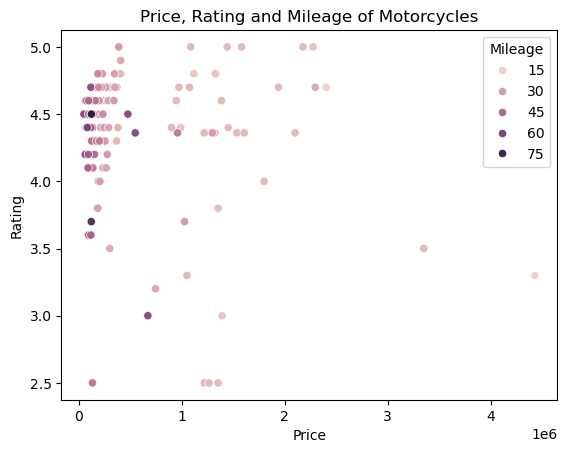

In [145]:
# How do motorcycle Price and Rating vary with Mileage across different motorcycles?
sns.scatterplot(data=df,x='Price',y='Rating',hue='Mileage')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.title('Price, Rating and Mileage of Motorcycles')
plt.show()

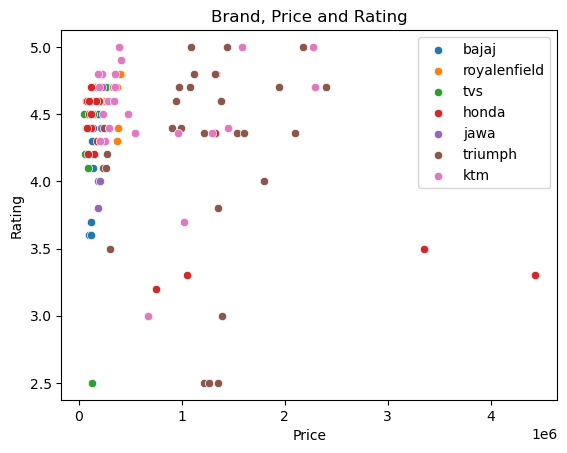

In [146]:
# How do Brand, Price, and Rating interact across different motorcycle manufacturers?
brands = df['Brand']
for i in brands.unique():
    data = df[df['Brand'] == i]
    sns.scatterplot(data=data,x='Price',y='Rating',label=i)
plt.title('Brand, Price and Rating')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.legend()
plt.show()